In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
# 1. Ensure Python can locate the 'src/' directory from the 'notebooks/' folder
sys.path.append(str(Path("../").resolve()))

# Import only the main processing function
from src.filtering import process_all_jv_curves

# Set plot aesthetics
sns.set_theme(style="whitegrid")

# 2. Load raw data into memory (read-only)
PROCESSED_DIR = Path("../data/processed/outdoor")
device_dirs = [d.name for d in PROCESSED_DIR.iterdir() if d.is_dir()]
raw_data_dict = {}

for name in device_dirs:
    parquet_path = PROCESSED_DIR / name / f"{name}_jv.parquet"

    if parquet_path.exists():
        df = pd.read_parquet(parquet_path)

        if not df.empty:
            raw_data_dict[name] = df

print(f"✅ Loaded raw datasets for {len(raw_data_dict)} cells.")


✅ Loaded raw datasets for 8 cells.


In [4]:
def visualize_filter_discards_exclusive(jv_df: pd.DataFrame, filter_col: str, all_filters: list, n_rows: int = 3, n_cols: int = 3):
    """
    Finds and plots the curves that were discarded exclusively by a specific filter
    (meaning they passed all other filters without issue).
    """
    # 1. This filter must have failed (True/1)
    target_fail = jv_df[filter_col].fillna(0).astype(bool)

    # 2. All other filters must have passed (False/0)
    other_filters = [f for f in all_filters if f != filter_col]
    others_pass = (jv_df[other_filters].fillna(0) == 0).all(axis=1)

    # 3. The actual error curve is the intersection
    error_mask = target_fail & others_pass
    error_curves = jv_df[error_mask]['id_curve'].unique()

    if len(error_curves) == 0:
        print(f"✅ No curves were discarded *exclusively* by '{filter_col}'.")
        return

    # 4. Select random curves
    n_samples = min(len(error_curves), n_rows * n_cols)
    sampled_curves = np.random.choice(error_curves, n_samples, replace=False)

    # 5. Prepare the figure
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
    fig.suptitle(
        f'Discarded exclusively by: {filter_col}\n(Total exclusive: {len(error_curves)})',
        fontsize=16, fontweight='bold', y=1.02
    )
    axes = axes.flatten()

    # 6. Plot each curve
    for i, curve_id in enumerate(sampled_curves):
        ax = axes[i]
        curve_data = jv_df[jv_df['id_curve'] == curve_id]
        cell_name = curve_data['cell_name'].iloc[0]

        fwd = curve_data[curve_data['is_reverse'] == 0].sort_values('Voltage_V')
        rev = curve_data[curve_data['is_reverse'] == 1].sort_values('Voltage_V')

        if not fwd.empty:
            ax.plot(fwd['Voltage_V'] * 1000, fwd['Current_A'] * 1000,
                    label='Forward', color='tab:red', linestyle='-', alpha=0.9)
        if not rev.empty:
            ax.plot(rev['Voltage_V'] * 1000, rev['Current_A'] * 1000,
                    label='Reverse', color='orange', linestyle='--', alpha=0.9)

        ax.set_title(f'ID: {curve_id} | {cell_name}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Voltage (mV)', fontsize=10)
        ax.set_ylabel('Current (mA)', fontsize=10)
        ax.grid(True, linestyle='-', alpha=0.3)
        ax.tick_params(axis='both', which='major', labelsize=9)

        if i == 0:
            ax.legend(loc='best', fontsize=9)

    # Hide unused subplots if there are fewer curves than slots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


2026-08-15 22:09:52,421 [INFO] Filtering: Initiating physical filtering pipeline for 8 cells...
2026-08-15 22:09:52,426 [INFO] Filtering: Applying filter topology to cell: A162ALXP01
2026-08-15 22:10:45,693 [INFO] Filtering: Applying filter topology to cell: A164AB302c
2026-08-15 22:12:03,877 [INFO] Filtering: Applying filter topology to cell: A167AB344a
2026-08-15 22:12:53,024 [INFO] Filtering: Applying filter topology to cell: A170AB302
2026-08-15 22:13:04,563 [INFO] Filtering: Applying filter topology to cell: ASLRXAB341
2026-08-15 22:14:05,590 [INFO] Filtering: Applying filter topology to cell: M0
2026-08-15 22:14:56,145 [INFO] Filtering: Applying filter topology to cell: M83AB302
2026-08-15 22:15:12,981 [INFO] Filtering: Applying filter topology to cell: P12
2026-08-15 22:16:31,373 [INFO] Filtering: Concatenating processed chunks into global DataFrame...
2026-08-15 22:18:04,803 [INFO] Filtering: Generating global diagnostics report...
2026-08-15 22:20:35,539 [INFO] Filtering: 
===


Generating plots for filter: is_low_voltage


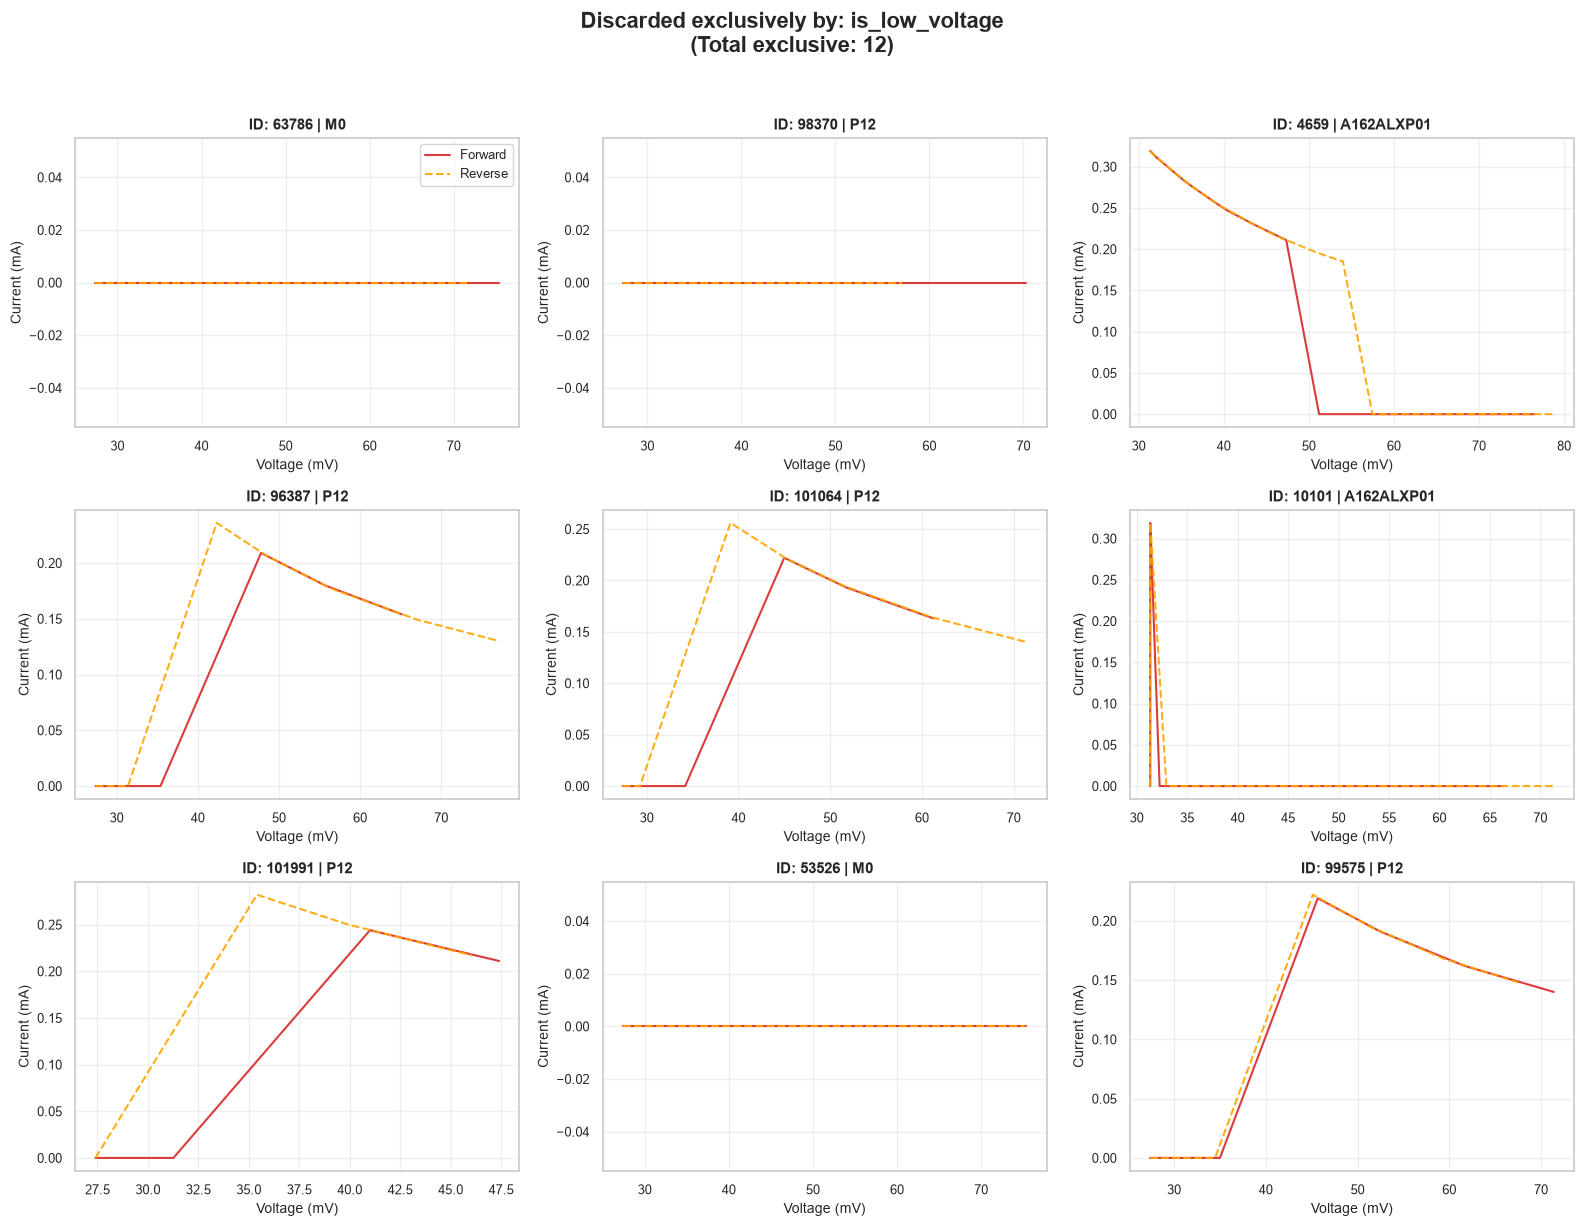


Generating plots for filter: is_low_current
✅ No curves were discarded *exclusively* by 'is_low_current'.

Generating plots for filter: is_night_time
✅ No curves were discarded *exclusively* by 'is_night_time'.

Generating plots for filter: is_curve_frozen


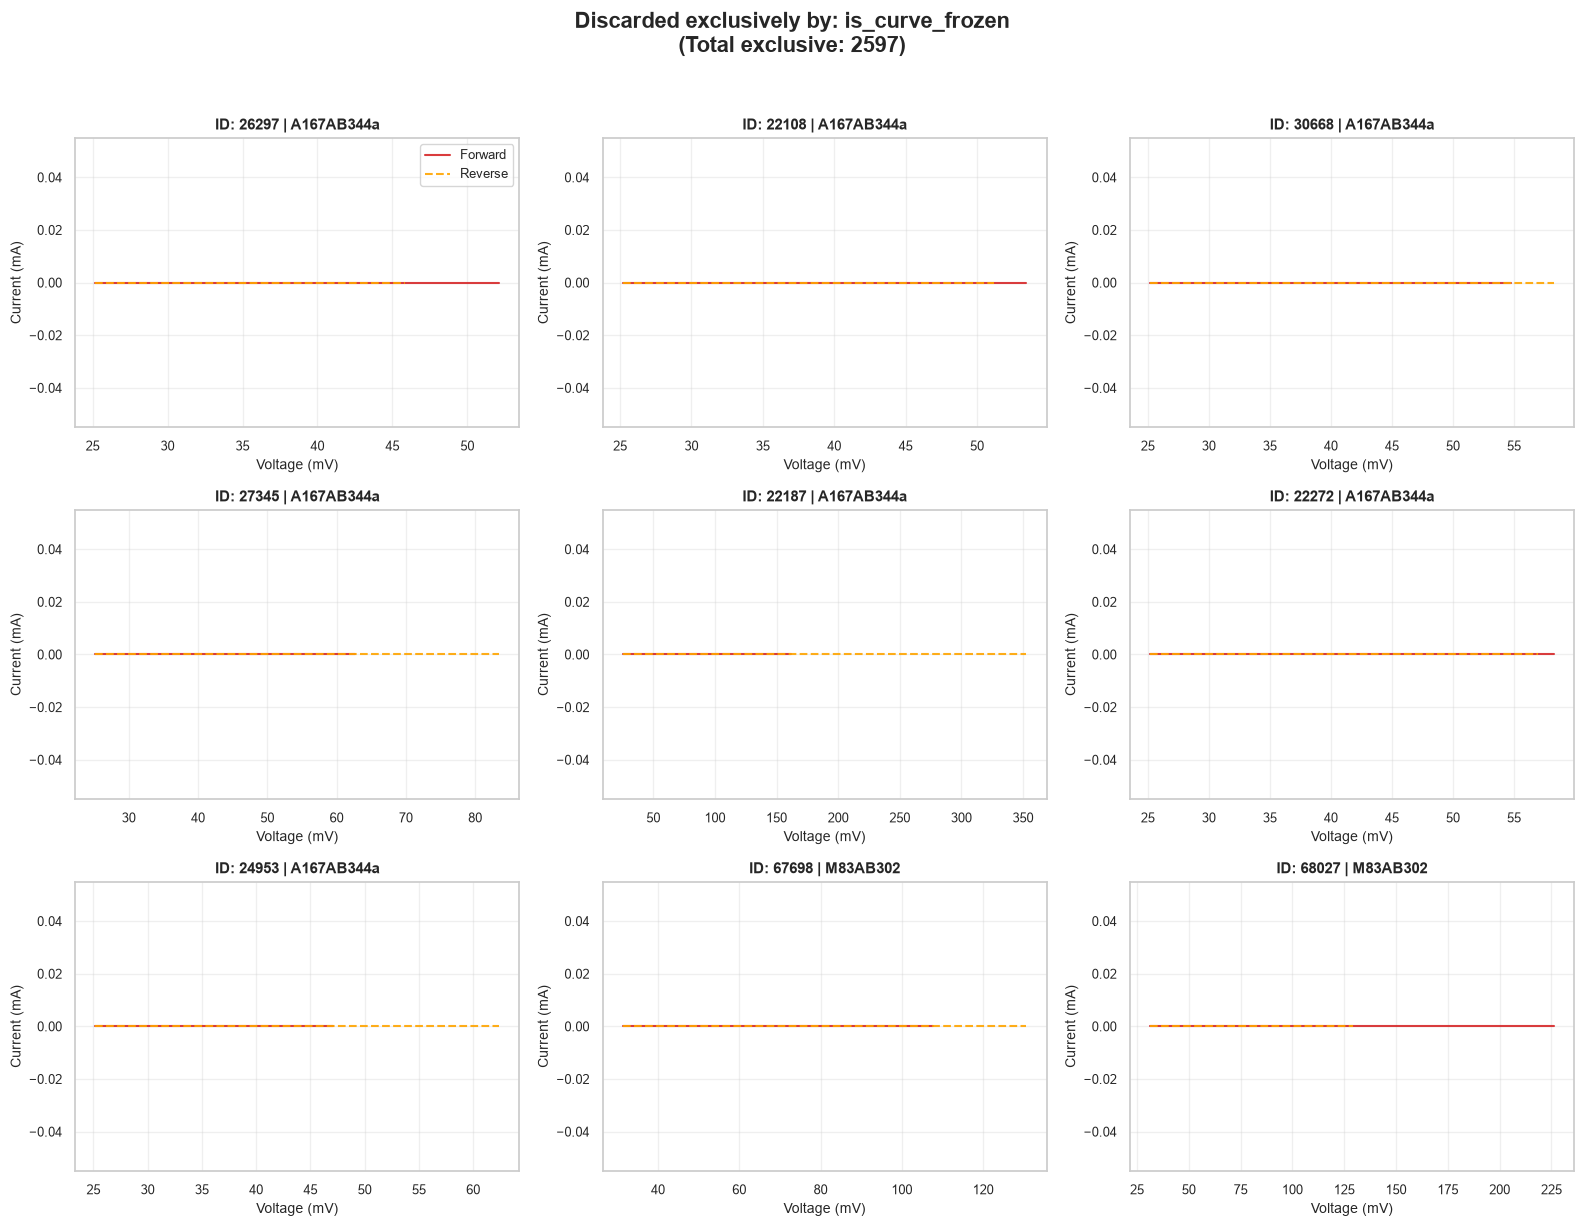


Generating plots for filter: is_corrupted
✅ No curves were discarded *exclusively* by 'is_corrupted'.

Generating plots for filter: is_spike_error


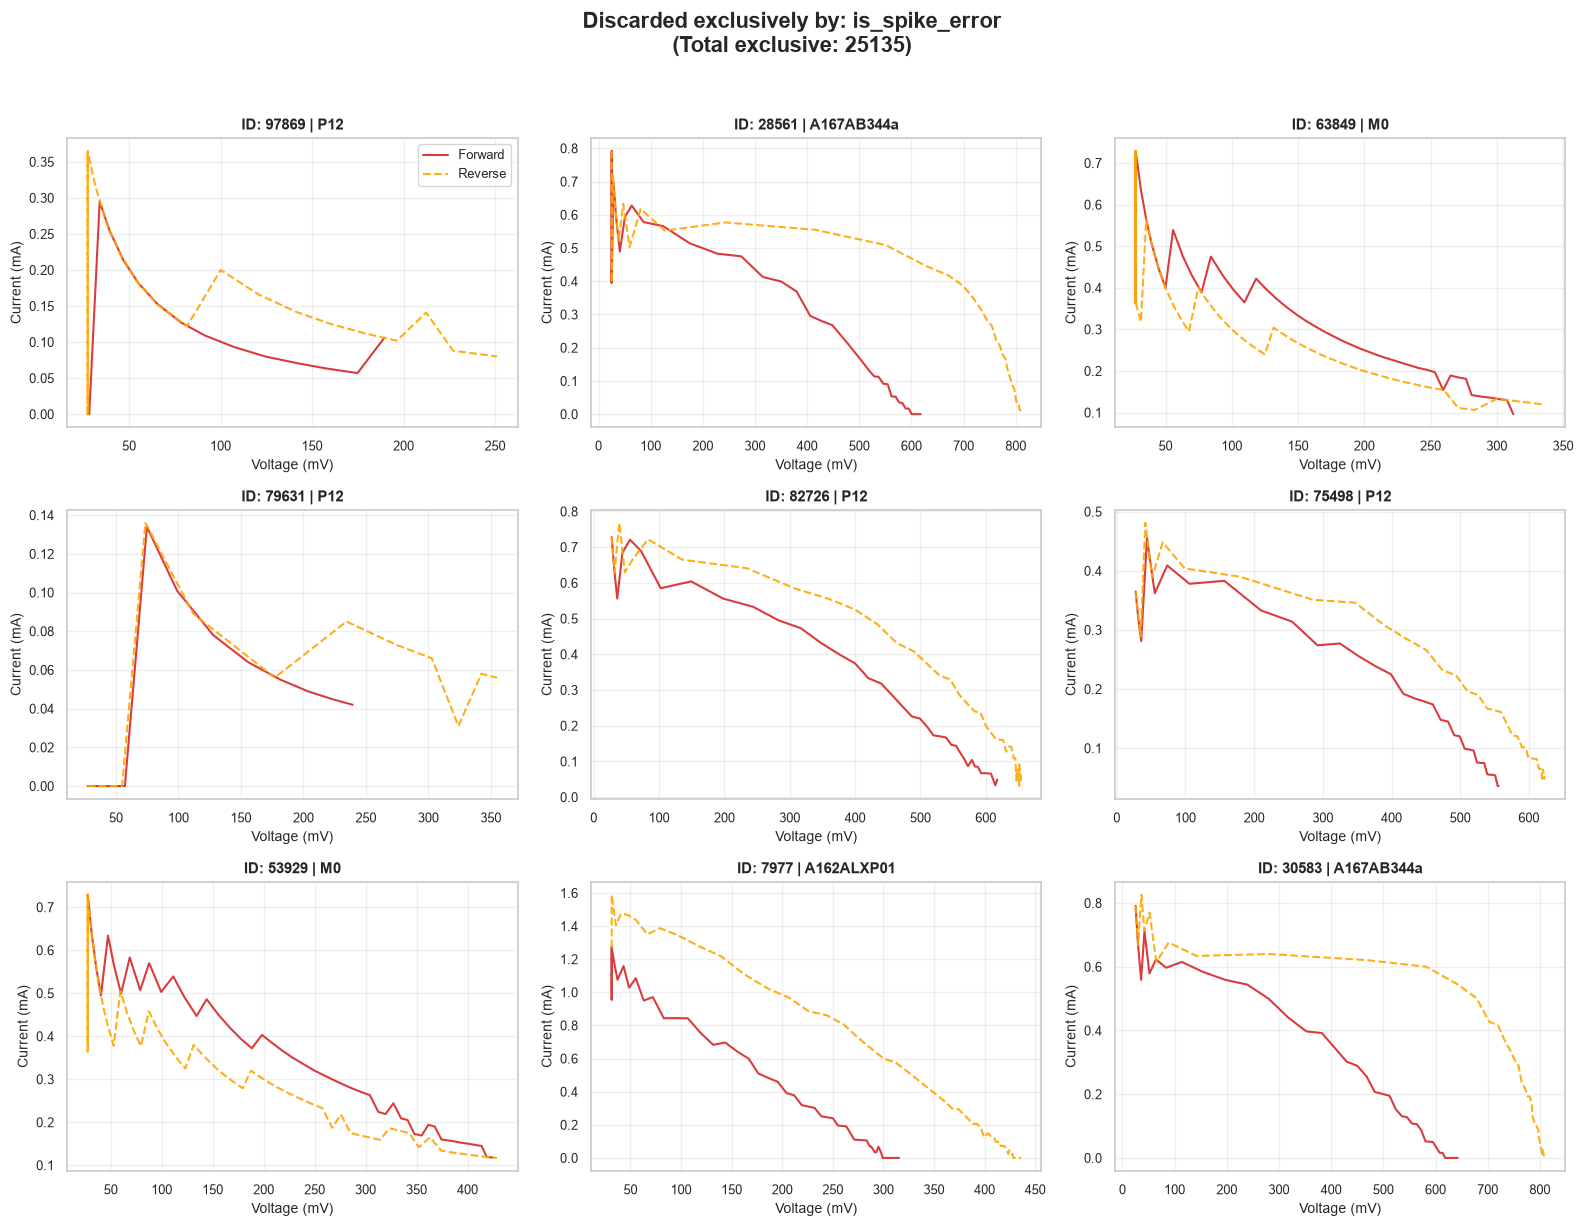


Generating plots for filter: is_asymmetric


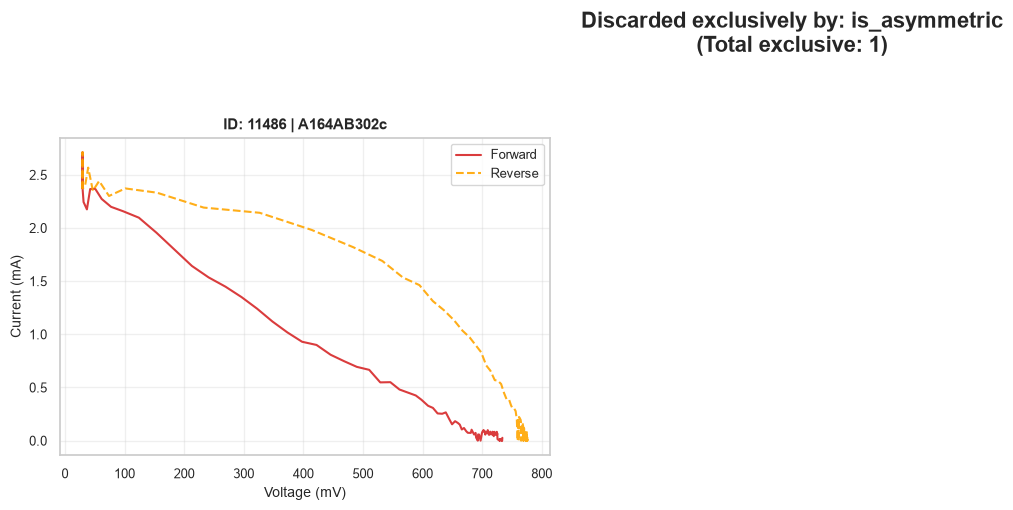


Generating plots for filter: is_mean_mismatch


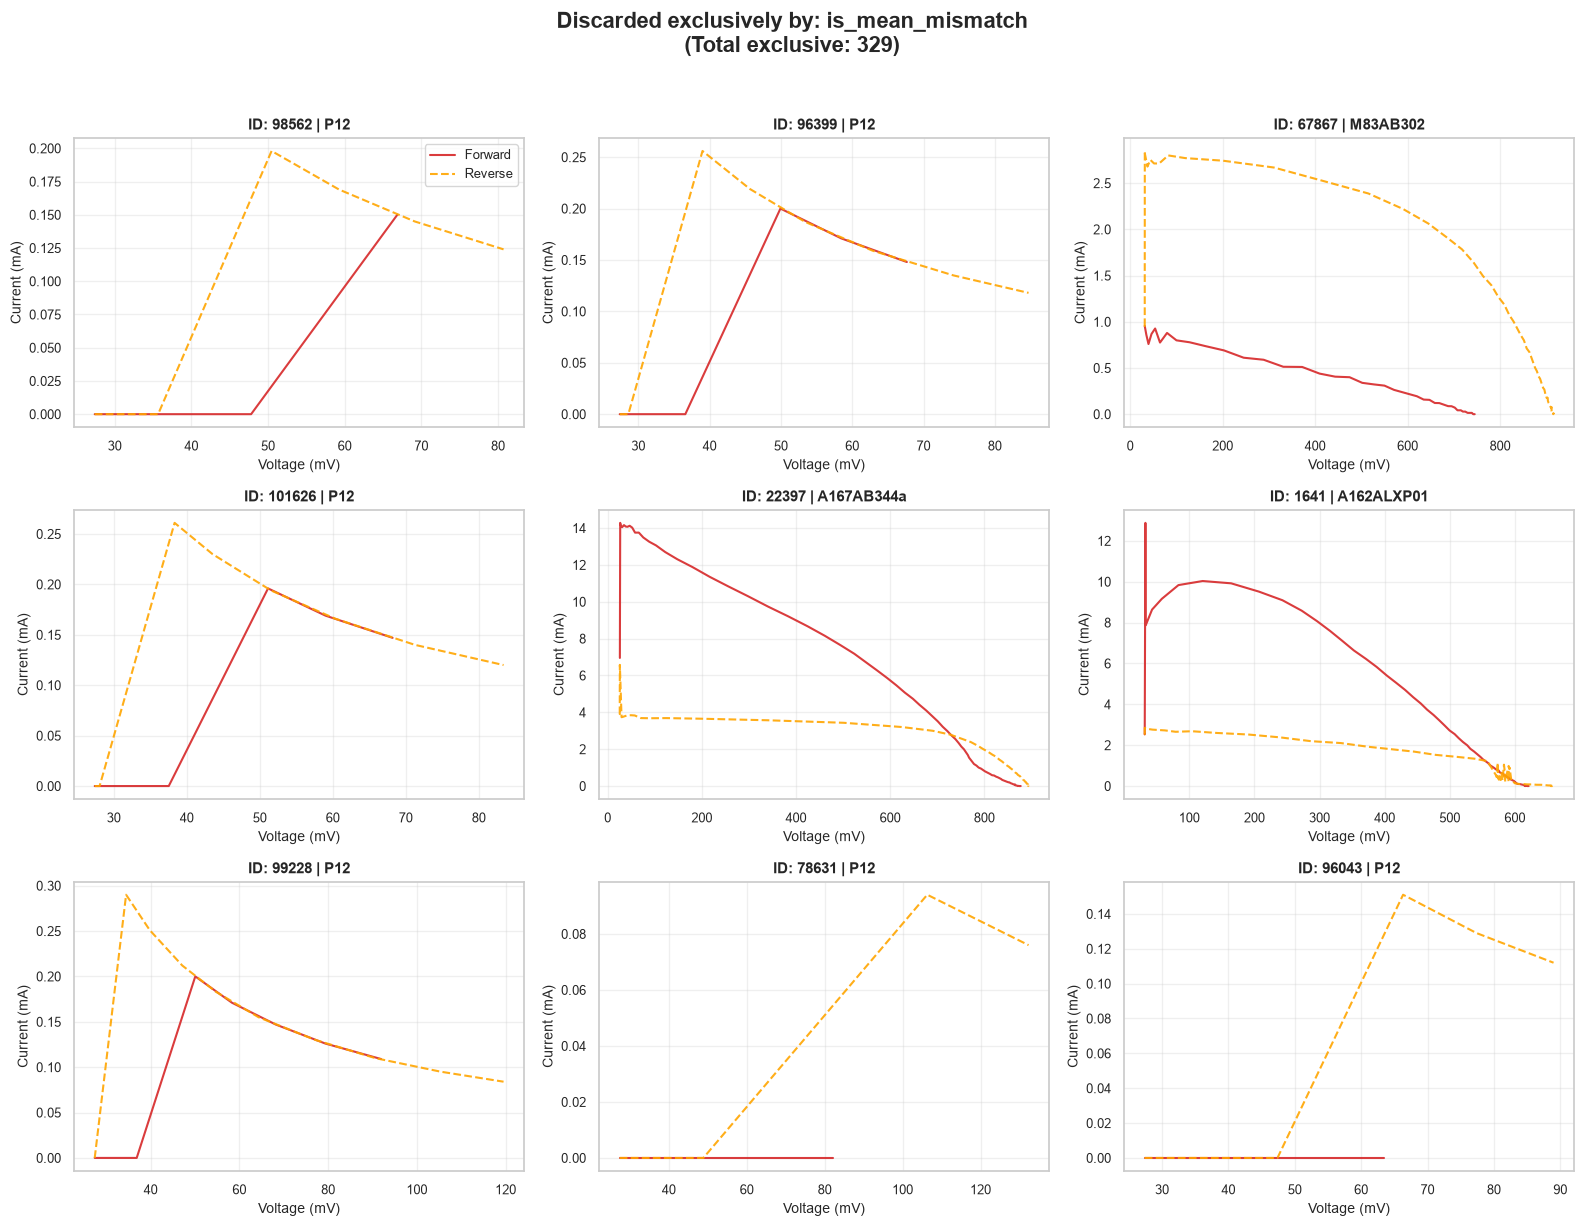

In [6]:
# Experimentation and tuning (test dataset)
# Modify the thresholds here and run the cell to see how the plots change:
jv_test = process_all_jv_curves(
    raw_dfs_dict=raw_data_dict,
    v_span_threshold_mv=50,      # Voltage range for low irradiance
    i_span_threshold_A=0.0001,   # Wide current range (100 µA)
    freeze_run_threshold=15,     # Detection of frozen readings
    spike_tol=2,                 # Keep isolated spikes under control (max 3)
)

# Interactive visualization
filters_to_review = [
    'is_low_voltage', 'is_low_current', 'is_night_time', 
    'is_curve_frozen', 'is_corrupted', 'is_spike_error', 
    'is_asymmetric', 'is_mean_mismatch'
]

for TARGET_FILTER in filters_to_review:
    print(f"\nGenerating plots for filter: {TARGET_FILTER}")
    visualize_filter_discards_exclusive(
        jv_df=jv_test, 
        filter_col=TARGET_FILTER,  
        all_filters=filters_to_review
    )


Generating visual audit for valid curves...


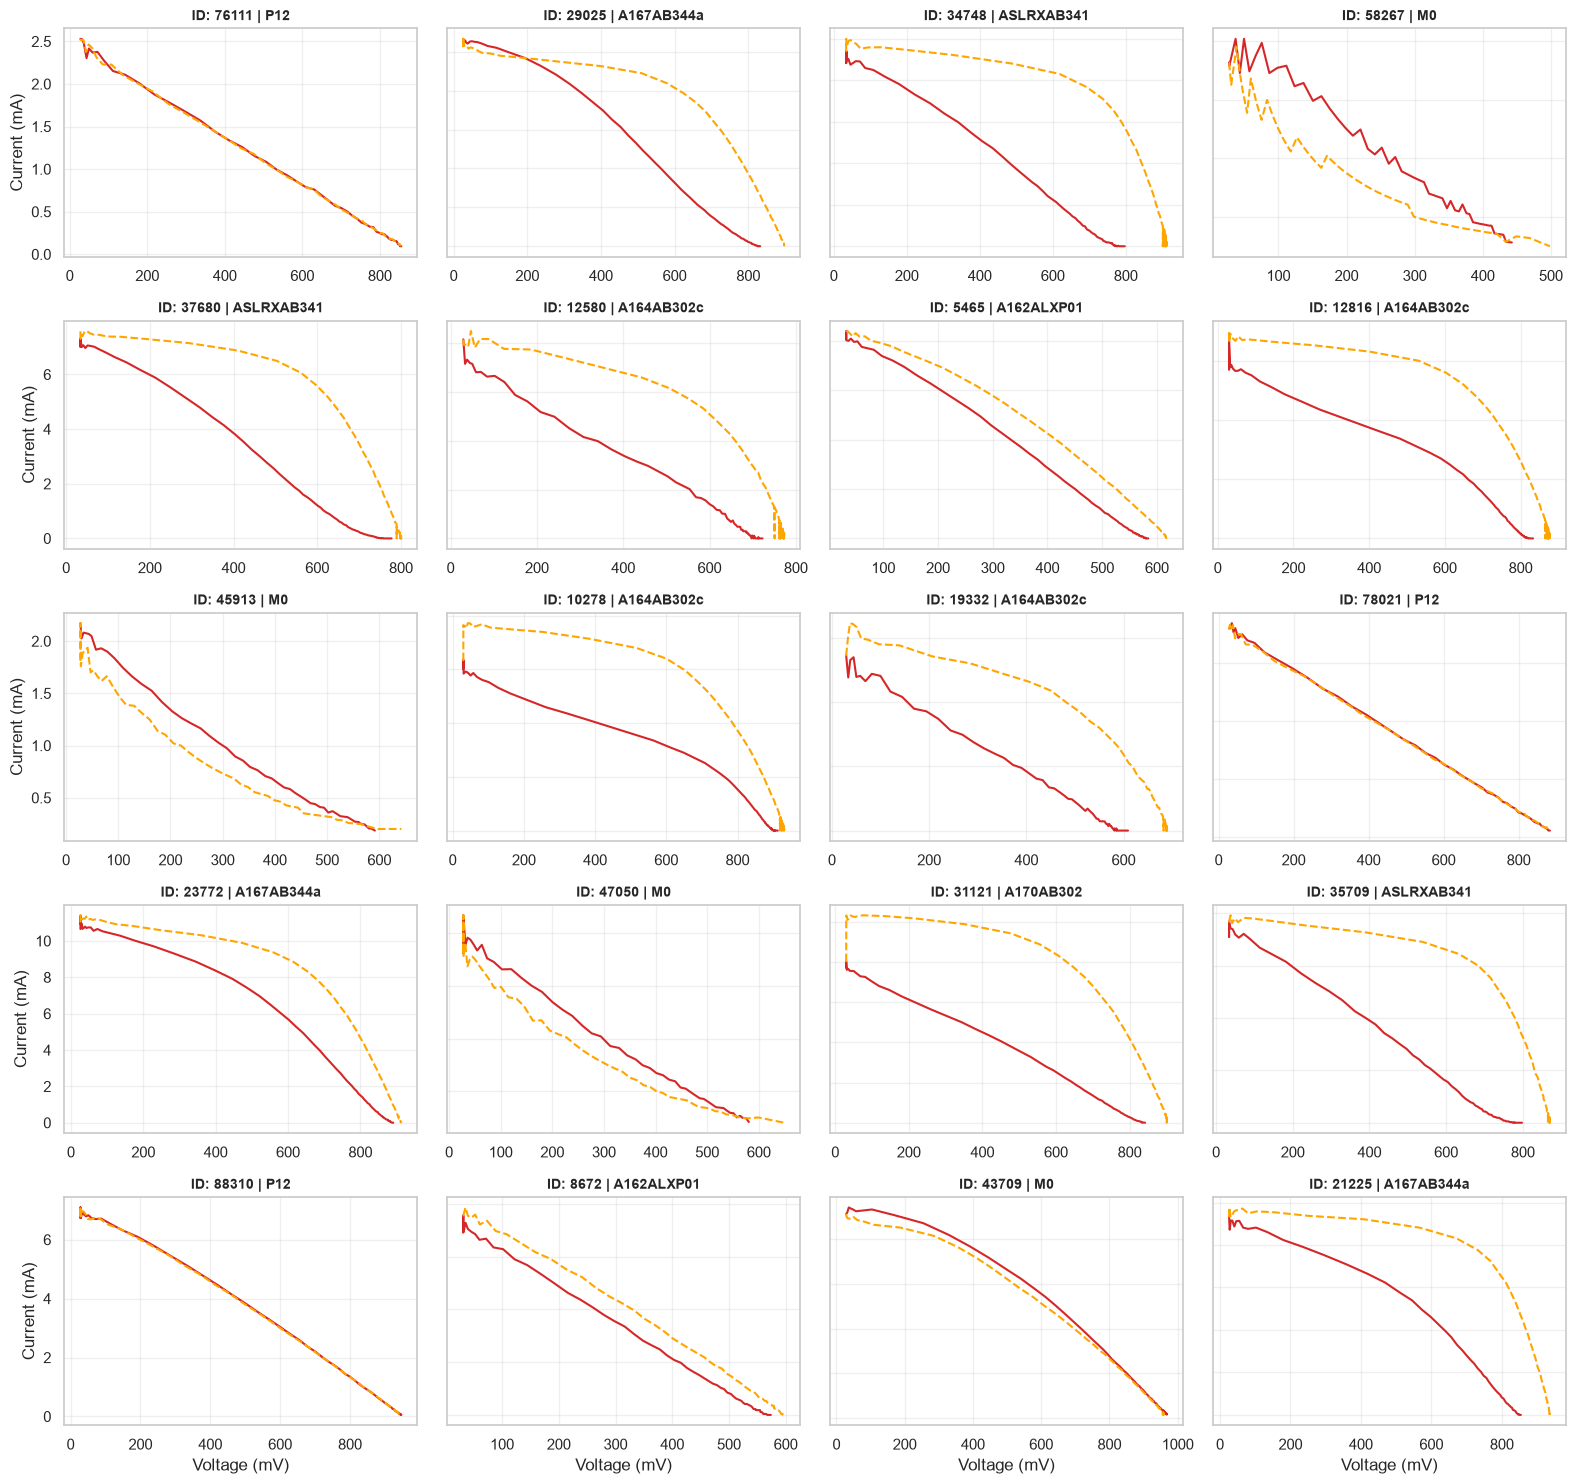

In [5]:
def audit_valid_dataset(jv: pd.DataFrame, num_samples: int = 12):
    """
    Randomly selects VALID curves and displays them in a grid
    for a quick visual audit of the filtered dataset.
    """
    # Isolate only the curves that passed the filter
    valid_jv = jv[jv['is_curve_valid'] == 1]
    valid_ids = valid_jv['id_curve'].unique()

    if len(valid_ids) == 0:
        print("⚠️ No valid curves found to audit.")
        return

    # Choose random IDs
    sample_ids = np.random.choice(valid_ids, size=min(num_samples, len(valid_ids)), replace=False)

    # Set up the grid (4 columns)
    cols = 4
    rows = (len(sample_ids) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 3 * rows))
    
    # Handle the case where there is only 1 row (axes would not be a 2D array)
    if rows == 1 and cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i, cid in enumerate(sample_ids):
        ax = axes[i]
        curve = valid_jv[valid_jv['id_curve'] == cid]
        cell_name = curve['cell_name'].iloc[0]

        # Separate and sort Fwd and Rev to plot Current
        fwd = curve[curve['is_reverse'] == 0].sort_values('Voltage_V')
        rev = curve[curve['is_reverse'] == 1].sort_values('Voltage_V')

        if not fwd.empty:
            ax.plot(fwd['Voltage_V'] * 1000, fwd['Current_A'] * 1000, color='tab:red', label='Fwd')
        if not rev.empty:
            ax.plot(rev['Voltage_V'] * 1000, rev['Current_A'] * 1000, color='orange', linestyle='--', label='Rev')

        ax.set_title(f"ID: {cid} | {cell_name}", fontsize=10, fontweight='bold')
        ax.grid(True, alpha=0.3)

        # Clean axes to keep the grid looking neat
        if i % cols == 0:
            ax.set_ylabel('Current (mA)')
        else:
            ax.set_yticklabels([])

        if i >= len(sample_ids) - cols:
            ax.set_xlabel('Voltage (mV)')

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

# Run the audit on the interactive test dataset
print("\nGenerating visual audit for valid curves...")
audit_valid_dataset(jv_test, num_samples=20)

In [6]:
df = pd.read_parquet(PROCESSED_DIR / 'jv_dataset_labeled.parquet')

In [ ]:
df[df['label_curve'] == -1]

,Timestamp,Voltage_V,Current_A,ScanDirection,curve,cell_name,cell_id,is_reverse,v_max,v_min,...,fwd_len,rev_len,is_asymmetric,fwd_mean,rev_mean,is_mean_mismatch,is_curve_valid,id_curve,label_curve,pseudo_FF
0,2026-03-14 06:05:38.665265,0.09026,-0.0,Reverse,1,A162ALXP01,0,1,0.09026,0.03132,...,191.0,196.0,False,0.0,0.0,False,0,0,-1,NaN
1,2026-03-14 06:05:38.805223,0.08973,-0.0,Reverse,1,A162ALXP01,0,1,0.09026,0.03132,...,191.0,196.0,False,0.0,0.0,False,0,0,-1,NaN
2,2026-03-14 06:05:39.092824,0.08826,-0.0,Reverse,1,A162ALXP01,0,1,0.09026,0.03132,...,191.0,196.0,False,0.0,0.0,False,0,0,-1,NaN
3,2026-03-14 06:05:39.236785,0.08786,-0.0,Reverse,1,A162ALXP01,0,1,0.09026,0.03132,...,191.0,196.0,False,0.0,0.0,False,0,0,-1,NaN
4,2026-03-14 06:05:39.380629,0.08746,-0.0,Reverse,1,A162ALXP01,0,1,0.09026,0.03132,...,191.0,196.0,False,0.0,0.0,False,0,0,-1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26179635,2026-05-04 21:58:44.548791,0.02738,0.0,Forward,34255,P12,7,0,0.02738,0.02738,...,85.0,85.0,False,0.0,0.0,False,0,104366,-1,NaN
26179636,2026-05-04 21:58:44.692679,0.02738,0.0,Forward,34255,P12,7,0,0.02738,0.02738,...,85.0,85.0,False,0.0,0.0,False,0,104366,-1,NaN
26179637,2026-05-04 21:58:44.836776,0.02738,0.0,Forward,34255,P12,7,0,0.02738,0.02738,...,85.0,85.0,False,0.0,0.0,False,0,104366,-1,NaN
26179638,2026-05-04 21:58:44.980562,0.02738,0.0,Forward,34255,P12,7,0,0.02738,0.02738,...,85.0,85.0,False,0.0,0.0,False,0,104366,-1,NaN


: 